# Updatining Predictions for Unlabeled Trials

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import torch
import deeplabcut
import DLCsupport as dlcs
import deeplabcut as dlc
import matplotlib.pyplot as plt
from importlib.util import spec_from_file_location, module_from_spec
import glob
import xrommtools_copy as xt
import re
import shutil

from PIL import Image
from PostAnalysis_review import find_darkest_pixel, collect_images, _correct_camera_frame, _extract_camera_predictions, find_dark_blob_centroid



module_path = r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\Code-Testing\data-converters.py"
spec = spec_from_file_location("dc", module_path)
dc = module_from_spec(spec)
spec.loader.exec_module(dc)

module_path = r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\Code-Testing\xrommtools.py"
spec = spec_from_file_location("xt", module_path)
xt = module_from_spec(spec)
spec.loader.exec_module(xt)

In [41]:

def snap_combined_predictions_to_dark_pixels(
    pred_csv,
    cam1_dir,
    cam2_dir,
    out_csv=None,
    window_size=5,
):
    """Snap each predicted keypoint to the nearest dark pixel in the matching frame image."""
    pred_csv = Path(pred_csv)
    cam1_dir = Path(cam1_dir)
    cam2_dir = Path(cam2_dir)

    df = pd.read_csv(pred_csv)
    out = df.copy()

    images_by_cam = {
        "cam1": collect_images(cam1_dir),
        "cam2": collect_images(cam2_dir),
    }

    # Parse columns like bodypart_cam1_X / bodypart_cam2_Y
    col_pattern = re.compile(r"(?P<bodypart>.+)_cam(?P<cam>[12])_(?P<coord>[XY])$")
    col_map = {}
    bodyparts = set()
    for col in out.columns:
        match = col_pattern.match(str(col))
        if match is None:
            continue
        bp = str(match.group("bodypart"))
        cam = f"cam{match.group('cam')}"
        coord = str(match.group("coord")).upper()
        col_map[(bp, cam, coord)] = col
        bodyparts.add(bp)

    if not bodyparts:
        raise ValueError(
            "No prediction columns found in combined format (expected bodypart_cam1_X style columns)."
        )

    bodyparts = sorted(bodyparts)

    n_frames = len(out)
    print(f"Snapping {len(bodyparts)} bodyparts across {n_frames} frames...")

    for frame_pos in range(n_frames):
        if frame_pos % 100 == 0:
            print(f"  frame {frame_pos}/{n_frames - 1}")

        for cam in ("cam1", "cam2"):
            images = images_by_cam[cam]
            if not (0 <= frame_pos < len(images)):
                continue

            with Image.open(images[frame_pos]) as image_file:
                gray_img = np.asarray(image_file.convert("L"))

            occupied_pixels = set()

            for bp in bodyparts:
                xcol = col_map.get((bp, cam, "X"))
                ycol = col_map.get((bp, cam, "Y"))
                if xcol is None or ycol is None:
                    continue

                x_val = pd.to_numeric(out.at[frame_pos, xcol], errors="coerce")
                y_val = pd.to_numeric(out.at[frame_pos, ycol], errors="coerce")
                if not (np.isfinite(x_val) and np.isfinite(y_val)):
                    continue

                rr, cc = find_darkest_pixel(
                    gray_img,
                    row=float(y_val),
                    col=float(x_val),
                    occupied=occupied_pixels,
                    window_size=int(window_size),
                )

                out.at[frame_pos, xcol] = float(cc)
                out.at[frame_pos, ycol] = float(rr)

    if out_csv is None:
        out_csv = pred_csv.with_name(f"{pred_csv.stem}_snapped_dark.csv")
    else:
        out_csv = Path(out_csv)

    out.to_csv(out_csv, index=False)
    print(f"Saved snapped predictions: {out_csv}")
    return out_csv, out


# snapped_csv, snapped_df = snap_combined_predictions_to_dark_pixels(
#     pred_csv=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\ModelUpdate-Predicted2DPoints.csv",
#     cam1_dir=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\Cam1",
#     cam2_dir=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\Cam2",
#     # out_csv=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\ModelUpdate-Predicted2DPoints-snapped-dark.csv",
#     window_size=4,
# )

# snapped_df.head()

In [ ]:
from pathlib import Path
import pandas as pd
import time
import cv2


def correct_frames_from_trial_dir(
    trial_dir: Path,
    frames_to_correct,
    max_match_dist: float = 15.0,
    pred_csv_name: str = "ModelUpdateMonday-Predicted2DPoints.csv",
    cam_names=("Cam1", "Cam2"),
    image_collector=None,
    correction_fn=None,
    output_suffix: str = "df_corrected.csv",
    verbose: bool = True,
):
    """
    Run correction pipeline using a single experiment/trial directory.

    Expected structure:
        trial_dir/
            pred_csv_name
            Cam1/
            Cam2/
    """

    trial_dir = Path(trial_dir)

    if image_collector is None:
        raise ValueError("image_collector must be provided")

    if correction_fn is None:
        raise ValueError("correction_fn must be provided")

    # ----------------------------
    # Resolve paths automatically
    # ----------------------------
    pred_csv = trial_dir / pred_csv_name
    if not pred_csv.exists():
        raise FileNotFoundError(f"Missing CSV: {pred_csv}")

    cam_dirs = {
        cam: trial_dir / cam
        for cam in cam_names
    }

    out_csv = trial_dir / output_suffix

    # ----------------------------
    # Load data
    # ----------------------------
    df = pd.read_csv(pred_csv)
    df_corrected = df.copy(deep=True)

    # ----------------------------
    # Load images
    # ----------------------------
    image_paths = {
        cam: image_collector(folder)
        for cam, folder in cam_dirs.items()
    }

    cams = list(image_paths.keys())

    if len(cams) >= 2:
        n0 = len(image_paths[cams[0]])
        for c in cams[1:]:
            if len(image_paths[c]) != n0:
                print(
                    f"Cam mismatch: {cams[0]}={n0}, {c}={len(image_paths[c])}"
                )

    # ----------------------------
    # Validate frames
    # ----------------------------
    frames_to_correct = sorted(set(int(x) for x in frames_to_correct))

    valid_frames = [
        i for i in frames_to_correct
        if 0 <= i < len(df_corrected)
        and all(i < len(image_paths[c]) for c in cams)
    ]

    if not valid_frames:
        raise ValueError("No valid frames after filtering.")

    # ----------------------------
    # Processing
    # ----------------------------
    t0 = time.perf_counter()

    for n, frame_idx in enumerate(valid_frames, start=1):

        row = df_corrected.iloc[frame_idx]

        for camera in cams:

            img_path = image_paths[camera][frame_idx]

            gray = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
            if gray is None:
                continue

            updates = correction_fn(
                image=gray,
                row=row,
                camera=camera.lower(),
                max_match_dist=max_match_dist,
            )

            if updates:
                df_corrected.loc[
                    df_corrected.index[frame_idx],
                    list(updates.keys())
                ] = list(updates.values())

        if verbose and (n % 25 == 0 or n == len(valid_frames)):
            print(f"Corrected {n}/{len(valid_frames)} frames")

    elapsed = time.perf_counter() - t0

    df_corrected.to_csv(out_csv, index=False)

    if verbose:
        print(f"Saved: {out_csv}")
        print(f"Done {len(valid_frames)} frames in {elapsed:.1f}s")

    return df_corrected

In [42]:
def predict_trial_from_jpg_stacks(
    config_path,
    bird,
    trial_number,
    base_processing_dir=Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData"),
    fps=500,
    batchsize=16,
    save_as_csv=True,
    xma_base_name="ModelUpdate",
    snap_window_size=4,
):
    """
    End-to-end trial prediction pipeline:
    1) Convert Cam1/Cam2 JPG stacks to AVI
    2) Run DLC prediction from config.yaml
    3) Convert DLC CSV outputs to XMA combined 2D points CSV
    4) Snap combined predictions to nearest dark pixels

    Parameters
    ----------
    config_path : str or Path
        Path to a DeepLabCut config.yaml file.
    bird : str
        Bird folder name under ProcessingData (e.g., "Tulio", "DavidBowie").
    trial_number : int or str
        Trial number used to build Trial{n} (e.g., 1 -> Trial1).
    base_processing_dir : Path
        Root folder containing bird trial data.
    fps : int
        FPS used to build AVI files from JPG stacks.
    batchsize : int
        Batch size used by dlc.analyze_videos.
    save_as_csv : bool
        Whether to save predictions as CSV.
    xma_base_name : str
        Prefix used by xt.dlc_to_xma for output naming.
    snap_window_size : int
        Search window size used when snapping to dark pixels.
    """
    config_path = Path(config_path)
    trial_dir = Path(base_processing_dir) / str(bird) / f"Trial{trial_number}"

    cam1_dir = trial_dir / "Cam1"
    cam2_dir = trial_dir / "Cam2"
    cam1_avi = trial_dir / "Cam1.avi"
    cam2_avi = trial_dir / "Cam2.avi"

    if not cam1_dir.exists() or not cam2_dir.exists():
        raise FileNotFoundError(
            f"Expected Cam1/Cam2 folders in {trial_dir}, but one or both are missing."
        )
    print("Converting Cine Image stacks to AVI videos")
    # 1) Build videos from image stacks
    dc.jpg_stack_to_avi(input_folder=cam1_dir, output_path=cam1_avi, fps=int(fps))
    dc.jpg_stack_to_avi(input_folder=cam2_dir, output_path=cam2_avi, fps=int(fps))
    print("Now To Analyze the videos with existing model!")
    # 2) Run prediction using the provided DLC config
    dlc.analyze_videos(
        str(config_path),
        [str(cam1_avi), str(cam2_avi)],
        save_as_csv=bool(save_as_csv),
        destfolder=str(trial_dir),
        batchsize=int(batchsize),
    )

    # 3) Find newest DLC CSV outputs and convert to XMA combined format
    cam1_candidates = sorted(
        trial_dir.glob("Cam1DLC*.csv"),
        key=lambda path: path.stat().st_mtime,
    )
    cam2_candidates = sorted(
        trial_dir.glob("Cam2DLC*.csv"),
        key=lambda path: path.stat().st_mtime,
    )

    if not cam1_candidates or not cam2_candidates:
        raise FileNotFoundError(
            f"Could not find Cam1DLC*.csv / Cam2DLC*.csv in {trial_dir} after prediction."
        )

    cam1_dlc_csv = cam1_candidates[-1]
    cam2_dlc_csv = cam2_candidates[-1]
    print("Converting predictions to XMA format")
    xt.dlc_to_xma(
        str(cam1_dlc_csv),
        str(cam2_dlc_csv),
        str(xma_base_name),
        str(trial_dir),
    )

    # 4) Snap the generated combined predictions to dark pixels
    pred_csv = trial_dir / f"{xma_base_name}-Predicted2DPoints.csv"
    if not pred_csv.exists():
        pred_candidates = sorted(
            trial_dir.glob("*-Predicted2DPoints.csv"),
            key=lambda path: path.stat().st_mtime,
        )
        if not pred_candidates:
            raise FileNotFoundError(
                f"Could not find a *-Predicted2DPoints.csv in {trial_dir} after dlc_to_xma."
            )
        pred_csv = pred_candidates[-1]
    print("Snapping predictions to darkest Pixel")
    snapped_csv, snapped_df = snap_combined_predictions_to_dark_pixels(
        pred_csv=str(pred_csv),
        cam1_dir=str(cam1_dir),
        cam2_dir=str(cam2_dir),
        window_size=int(snap_window_size),
    )

    print(f"Finished full pipeline for {bird} Trial{trial_number} -> {trial_dir}")
    return {
        "trial_dir": trial_dir,
        "cam1_avi": cam1_avi,
        "cam2_avi": cam2_avi,
        "cam1_dlc_csv": cam1_dlc_csv,
        "cam2_dlc_csv": cam2_dlc_csv,
        "pred_csv": pred_csv,
        "snapped_csv": Path(snapped_csv),
        "snapped_df": snapped_df,
    }


# Example usage (Trial 1)
# result = predict_trial_from_jpg_stacks(
#     config_path=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\Tulio\SmallSetTraining\Model\Tulio-Tyler_Finetune-2026-06-16\config.yaml",
#     bird="Tulio",
#     trial_number=1,
# )

In [59]:
from pathlib import Path
import glob
import shutil
import re
import time
import pandas as pd


def _active_update_roots(
    base_dir: str | Path,
    bird: str,
    trial_num: int,
) -> list[Path]:
    base_dir = Path(base_dir)
    return [
        base_dir / bird / "active_updates" / f"Trial{trial_num}",
        base_dir / bird / f"Trial{trial_num}" / "active_updates",
    ]


def _list_active_update_dirs(
    base_dir: str | Path,
    bird: str,
    trial_num: int,
) -> list[Path]:
    active_dirs: list[Path] = []
    seen: set[str] = set()

    for root in _active_update_roots(base_dir, bird, trial_num):
        if not root.exists():
            continue

        for path in sorted(p for p in root.iterdir() if p.is_dir()):
            resolved = str(path.resolve()).lower()
            if resolved in seen:
                continue
            seen.add(resolved)
            active_dirs.append(path)

    return active_dirs


def _resolve_active_update_dir(
    base_dir: str | Path,
    bird: str,
    trial_num: int,
    update_set: str | None = None,
) -> Path:
    active_dirs = _list_active_update_dirs(base_dir, bird, trial_num)

    if len(active_dirs) == 0:
        searched = "\n".join(str(path) for path in _active_update_roots(base_dir, bird, trial_num))
        raise FileNotFoundError(
            "No active update folders found. Checked:\n"
            f"{searched}"
        )

    if update_set is not None:
        matches = [path for path in active_dirs if path.name.lower() == update_set.lower()]
        if len(matches) == 0:
            options = ", ".join(path.name for path in active_dirs)
            raise FileNotFoundError(
                f"Update set '{update_set}' not found for {bird} Trial{trial_num}. "
                f"Available: {options}"
            )
        return matches[0]

    if len(active_dirs) == 1:
        return active_dirs[0]

    unified_matches = [path for path in active_dirs if path.name.lower() == "unified"]
    if len(unified_matches) == 1:
        return unified_matches[0]

    options = ", ".join(path.name for path in active_dirs)
    raise ValueError(
        f"Multiple active update folders found for {bird} Trial{trial_num}: {options}. "
        "Pass update_set=... to choose one explicitly."
    )


def train_update_model(
    bird: str,
    trial_num: int,
    snapshot_path: str | Path = None,
    epochs: int = 100,
    nframes: int = 30,
    frame_selection_seed: int = 42,
    task: str = "Canari",
    experimenter: str = "Tyler",
    finetune_experimenter: str = "Tyler_Finetune",
    base_dir: str | Path = (
        r"C:\Users\Salle-Cineradio\Documents\MachineLearning"
        r"\BirdSongs-MNHN\Testing\ProcessingData"
    ),
    update_set: str | None = None,
):
    """
    Create/update a DLC training dataset for a bird trial and train the model.

    Parameters
    ----------
    bird : str
        Bird name (e.g. 'DavidBowie')
    trial_num : int
        Trial number (e.g. 2)
    snapshot_path : str | Path
        Pretrained snapshot to fine-tune from.
    epochs : int
        Number of training epochs.
    nframes : int
        Frames sampled when building the DLC dataset.
    frame_selection_seed : int
        Random seed for frame selection.
    update_set : str | None
        Active update folder name to use, e.g. 'dino', 'displacement', or 'unified'.
    """

    src_trial = _resolve_active_update_dir(
        base_dir=base_dir,
        bird=bird,
        trial_num=trial_num,
        update_set=update_set,
    )

    if snapshot_path is None:
        if bird == "DavidBowie":
            snapshot_path = r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\Model519\n400_T17\Canari-Tyler-2026-05-22\dlc-models-pytorch\iteration-0\CanariMay22-trainset95shuffle1\train\snapshot-100.pt"
        elif bird == "Tulio":
            snapshot_path = r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial10\active_updates\dino\Model\Tulio-Tyler-2026-06-30\dlc-models-pytorch\iteration-0\TulioJun30-trainset95shuffle1\train\snapshot-100.pt"

    if not src_trial.exists():
        raise FileNotFoundError(f"Trial folder not found:\n{src_trial}")

    # ------------------------------------------------------------------
    # Create DLC project
    # ------------------------------------------------------------------
    models_dir = src_trial / "ModelsToTune"
    models_dir.mkdir(exist_ok=True)

    dummy_video = (
        Path(base_dir)
        / bird
        / f"Trial{trial_num}"
        / "Cam1.avi"
    )

    combined_config = dlcs.create_combined_project_if_missing(
        task=task,
        experimenter=finetune_experimenter,
        combined_project_root=models_dir,
        dummy_video=dummy_video,
    )

    # ------------------------------------------------------------------
    # Apply bird bodyparts to config
    # ------------------------------------------------------------------
    dlcs.apply_bird_bodyparts_to_configs(
        {bird: [combined_config]},
        strict=True,
    )

    # ------------------------------------------------------------------
    # Create clean training folder
    # ------------------------------------------------------------------
    clean_trial = src_trial / "ModelTraining"
    clean_trial.mkdir(parents=True, exist_ok=True)

    # Copy camera folders
    for cam_folder in ["Cam1", "Cam2"]:
        src = src_trial / cam_folder
        dst = clean_trial / cam_folder

        if dst.exists():
            shutil.rmtree(dst)

        shutil.copytree(src, dst)

    # ------------------------------------------------------------------
    # Prepare labels CSV
    # ------------------------------------------------------------------
    truth_csv = src_trial / "data" / "corrections_autosave.csv"

    if not truth_csv.exists():
        raise FileNotFoundError(f"Missing label file:\n{truth_csv}")

    df = pd.read_csv(truth_csv)

    coord_cols = [
        c for c in df.columns
        if re.search(r"_cam[12]_[XY]$", c)
    ]

    if len(coord_cols) == 0:
        raise ValueError("No coordinate columns matching *_cam[12]_[XY] found.")

    clean_points_csv = clean_trial / "UpdatedLabels-2Dpoints.csv"

    df[coord_cols].to_csv(clean_points_csv, index=False)

    # ------------------------------------------------------------------
    # Build DLC dataset
    # ------------------------------------------------------------------
    dataset_name = f"UpdateModelForTrial{trial_num}"

    dlcs.build_combined_dataset(
        combined_config=combined_config,
        data_path=clean_trial,
        dataset_name=dataset_name,
        experimenter=experimenter,
        nframes=nframes,
        frame_selection_seed=frame_selection_seed,
    )

    # ------------------------------------------------------------------
    # Train
    # ------------------------------------------------------------------
    t0 = time.perf_counter()

    dlcs.create_and_train(
        config_path=combined_config,
        epochs=epochs,
        snapshot_path=str(snapshot_path),
    )

    elapsed = time.perf_counter() - t0

    print(
        f"\nTraining complete"
        f"\nBird: {bird}"
        f"\nTrial: {trial_num}"
        f"\nUpdate set: {src_trial.name}"
        f"\nElapsed: {elapsed:.1f} sec ({elapsed/60:.1f} min)"
    )

    return {
        "bird": bird,
        "trial": trial_num,
        "update_set": src_trial.name,
        "config": combined_config,
        "elapsed_seconds": elapsed,
    }

## Correcting Frames Using Blob Detection Algorithm

In [44]:
import cv2
import pandas as pd


def snap_camera_predictions(
    video_path,
    dlc_df,
    camera,
):
    cap = cv2.VideoCapture(str(video_path))

    corrected_rows = []

    for frame_idx in range(len(dlc_df)):

        success, frame = cap.read()
        if not success:
            break

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        row = dlc_df.iloc[frame_idx].copy()

        occupied_pixels = set()

        pred_points, bodyparts = _extract_camera_predictions(
            row,
            camera=camera,
        )

        for (y_pred, x_pred), bp in zip(pred_points, bodyparts):

            rr, cc = find_dark_blob_centroid(
                gray,
                row=float(y_pred),
                col=float(x_pred),
                occupied=occupied_pixels,
                camera=camera,
                background_sigma=20.0,
                max_sigma=2.0,
                sigma_ratio=1.3,
                threshold=0.03,
                max_match_dist=15.0,
            )

            bp = str(bp)

            row[f"{bp}_{camera}_X"] = float(cc)
            row[f"{bp}_{camera}_Y"] = float(rr)

        corrected_rows.append(row)

    cap.release()

    return pd.DataFrame(corrected_rows)

## Correcting Frames Using Darkest Pixel Detection Algorithm

In [60]:
from pathlib import Path
import glob
import deeplabcut as dlc


def run_model_update(
    bird: str,
    trial_num: int,
    model_name: str = "ModelUpdateMonday",
    batchsize: int = 16,
    update_set: str | None = None,
):
    """
    Run DLC inference and convert outputs to XMA.

    Parameters
    ----------
    bird : str
        e.g. "Tulio"
    trial_num : int
        e.g. 3
    model_name : str
        XMA export name
    batchsize : int
        DLC batch size
    update_set : str | None
        Active update folder name to use, e.g. 'dino', 'displacement', or 'unified'.
    """

    base = Path(
        r"C:\Users\Salle-Cineradio\Documents\MachineLearning"
        r"\BirdSongs-MNHN\Testing\ProcessingData"
    )

    trial_dir = (
        base
        / bird
        / f"Trial{trial_num}"
    )

    src_trial = _resolve_active_update_dir(
        base_dir=base,
        bird=bird,
        trial_num=trial_num,
        update_set=update_set,
    )

    # ------------------------------------------------------------------
    # Locate DLC config
    # ------------------------------------------------------------------

    models_dir = src_trial / "ModelsToTune"
    configs = list(models_dir.rglob("config.yaml"))

    if len(configs) == 0:
        raise FileNotFoundError(
            f"No config.yaml found in:\n{models_dir}"
        )

    if len(configs) > 1:
        print(
            f"Multiple configs found. Using newest:\n"
            f"{max(configs, key=lambda p: p.stat().st_mtime)}"
        )

    config_path = max(
        configs,
        key=lambda p: p.stat().st_mtime,
    )

    # ------------------------------------------------------------------
    # Videos
    # ------------------------------------------------------------------

    cam1 = trial_dir / "Cam1.avi"
    cam2 = trial_dir / "Cam2.avi"

    if not cam1.exists():
        raise FileNotFoundError(cam1)

    if not cam2.exists():
        raise FileNotFoundError(cam2)

    # ------------------------------------------------------------------
    # Output folder
    # ------------------------------------------------------------------

    updated_dir = trial_dir / "Updated"
    updated_dir.mkdir(exist_ok=True)

    # ------------------------------------------------------------------
    # DLC inference
    # ------------------------------------------------------------------

    dlc.analyze_videos(
        str(config_path),
        [str(cam1), str(cam2)],
        save_as_csv=True,
        destfolder=str(updated_dir),
        batchsize=batchsize,
    )

    # ------------------------------------------------------------------
    # Locate generated CSVs
    # ------------------------------------------------------------------

    cam1_csvs = sorted(updated_dir.glob("Cam1*.csv"))
    cam2_csvs = sorted(updated_dir.glob("Cam2*.csv"))

    if len(cam1_csvs) == 0:
        raise FileNotFoundError("No Cam1 DLC csv found.")

    if len(cam2_csvs) == 0:
        raise FileNotFoundError("No Cam2 DLC csv found.")

    cam1_csv = max(cam1_csvs, key=lambda p: p.stat().st_mtime)
    cam2_csv = max(cam2_csvs, key=lambda p: p.stat().st_mtime)

    print(f"Using:\n{cam1_csv}\n{cam2_csv}")

    # ------------------------------------------------------------------
    # Load DLC outputs
    # ------------------------------------------------------------------

    cam1_df = pd.read_csv(cam1_csv)
    cam2_df = pd.read_csv(cam2_csv)

    # ------------------------------------------------------------------
    # Snap Cam1 predictions
    # ------------------------------------------------------------------

    cam1_df_corrected = snap_camera_predictions(
        cam1,
        cam1_df,
        camera="cam1",
    )

    # ------------------------------------------------------------------
    # Snap Cam2 predictions
    # ------------------------------------------------------------------

    cam2_df_corrected = snap_camera_predictions(
        cam2,
        cam2_df,
        camera="cam2",
    )

    # ------------------------------------------------------------------
    # Save corrected CSVs
    # ------------------------------------------------------------------

    cam1_corrected_csv = updated_dir / "Cam1_corrected.csv"
    cam2_corrected_csv = updated_dir / "Cam2_corrected.csv"

    cam1_df_corrected.to_csv(cam1_corrected_csv, index=False)
    cam2_df_corrected.to_csv(cam2_corrected_csv, index=False)

    print(f"Saved:\n{cam1_corrected_csv}")
    print(f"Saved:\n{cam2_corrected_csv}")

    # ------------------------------------------------------------------
    # DLC -> XMA using corrected coordinates
    # ------------------------------------------------------------------

    xt.dlc_to_xma(
        str(cam1_corrected_csv),
        str(cam2_corrected_csv),
        model_name,
        str(updated_dir),
    )

    # ------------------------------------------------------------------
    # Future post-processing
    # ------------------------------------------------------------------

    return {
        "config": config_path,
        "update_set": src_trial.name,
        "cam1_csv": cam1_csv,
        "cam2_csv": cam2_csv,
        "output_dir": updated_dir,
    }

In [41]:
run_model_update("Tulio", 5
                 )

Analyzing videos with C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial5\active_updates\dino\ModelsToTune\Canari-Tyler_Finetune-2026-06-25\dlc-models-pytorch\iteration-0\CanariJun25-trainset95shuffle1\train\snapshot-125.pt
Using scorer: DLC_Resnet50_CanariJun25shuffle1_snapshot_125
Starting to analyze C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial5\Cam2.avi
Video metadata: 
  Overall # of frames:    6001
  Duration of video [s]:  12.00
  fps:                    500.0
  resolution:             w=768, h=768

Running pose prediction with batch size 16


100%|██████████| 6001/6001 [02:50<00:00, 35.20it/s]


Saving results in C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial5\Updated\Cam2DLC_Resnet50_CanariJun25shuffle1_snapshot_125.h5 and C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial5\Updated\Cam2DLC_Resnet50_CanariJun25shuffle1_snapshot_125_full.pickle
Starting to analyze C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial5\Cam1.avi
Video metadata: 
  Overall # of frames:    6001
  Duration of video [s]:  12.00
  fps:                    500.0
  resolution:             w=768, h=768

Running pose prediction with batch size 16


100%|██████████| 6001/6001 [02:50<00:00, 35.17it/s]


Saving results in C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial5\Updated\Cam1DLC_Resnet50_CanariJun25shuffle1_snapshot_125.h5 and C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial5\Updated\Cam1DLC_Resnet50_CanariJun25shuffle1_snapshot_125_full.pickle
The videos are analyzed. Now your research can truly start!
You can create labeled videos with 'create_labeled_video'.
If the tracking is not satisfactory for some videos, consider expanding the training set. You can use the function 'extract_outlier_frames' to extract a few representative outlier frames.

Using:
C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial5\Updated\Cam1DLC_Resnet50_CanariJun25shuffle1_snapshot_125.csv
C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial5\Updated\Cam2DLC_Resnet50_CanariJun25shuffle1_snapshot_125.csv


{'config': WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/ProcessingData/Tulio/Trial5/active_updates/dino/ModelsToTune/Canari-Tyler_Finetune-2026-06-25/config.yaml'),
 'cam1_csv': WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/ProcessingData/Tulio/Trial5/Updated/Cam1DLC_Resnet50_CanariJun25shuffle1_snapshot_125.csv'),
 'cam2_csv': WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/ProcessingData/Tulio/Trial5/Updated/Cam2DLC_Resnet50_CanariJun25shuffle1_snapshot_125.csv'),
 'output_dir': WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/ProcessingData/Tulio/Trial5/Updated')}

# David Bodwie anlaysis

#### Trial 8: David Bowie

In [ ]:
src_trial = Path(
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\active_updates\dino"
)

models = src_trial / "ModelsToTune"
models.mkdir(exist_ok=True)
# 1) Ensure we have a real DLC project config.yaml to write labeled-data into
# Replace dummy_video with any existing video file you already use for project init.
combined_config = dlcs.create_combined_project_if_missing(
    task="Canari",
    experimenter="Tyler_Finetune",
    combined_project_root=models,
    dummy_video=Path(
        r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\Cam1.avi"
    ),
)

# edit the config.yaml to add our 2D points CSV as a scorer with appropriate bodyparts and skeleton info
bodyparts_apply_df = dlcs.apply_bird_bodyparts_to_configs(
        {"DavidBowie": [combined_config]},
        strict=True,
    )

# 2) Build a clean trial folder for xma_to_dlc

clean_trial = src_trial / "ModelTraining"
clean_trial.mkdir(parents=True, exist_ok=True)

# Copy camera folders
for cam_folder in ["Cam1", "Cam2"]:
    src = src_trial / cam_folder
    dst = clean_trial / cam_folder
    if dst.exists():
        shutil.rmtree(dst)
    shutil.copytree(src, dst)

# Pick truth CSV and keep only coordinate columns
truth_csv = src_trial / "data/corrections_autosave.csv" 
df = pd.read_csv(truth_csv)

coord_cols = [c for c in df.columns if re.search(r"_cam[12]_[XY]$", c)]
clean_df = df[coord_cols]

# Name contains 2Dpoints so xrommtools picks it first
clean_points_csv = clean_trial / "UpdatedLabels-2Dpoints.csv"
clean_df.to_csv(clean_points_csv, index=False)

# 3) Build dataset from cleaned trial
dlcs.build_combined_dataset(
    combined_config=combined_config,      # real config.yaml path
    data_path=clean_trial,                # folder containing csv + Cam1 + Cam2
    dataset_name="For_Test_20_Eval17_Dino_n400_s125",
    experimenter="Tyler",
    nframes=30,
    frame_selection_seed=42,
)

In [ ]:
import time
snapshot_path = (
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\Model519\n400_T17\Canari-Tyler-2026-05-22\dlc-models-pytorch\iteration-0\CanariMay22-trainset95shuffle1\train\snapshot-100.pt"
)
t0 = time.perf_counter()
dlcs.create_and_train(
    config_path=combined_config,
    epochs=100,
    snapshot_path=snapshot_path
)
elapsed = time.perf_counter() - t0
print(elapsed)

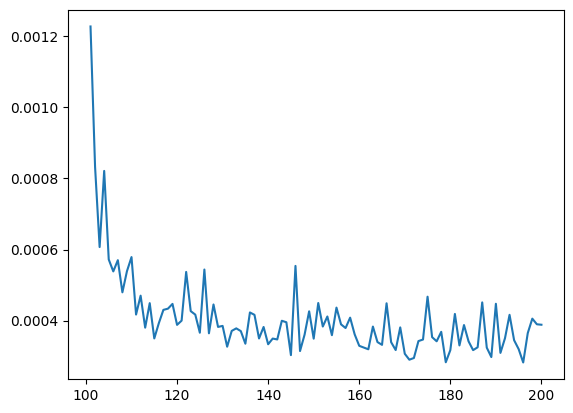

In [16]:
# plot learning stats
learning_stats = pd.read_csv(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\active_updates\dino\ModelsToTune\Canari-Tyler_Finetune-2026-06-12\dlc-models-pytorch\iteration-0\CanariJun12-trainset95shuffle1\train\learning_stats.csv")
learning_stats.head()
plt.plot(learning_stats["step"], learning_stats["losses/train.total_loss"], label="train_loss")

In [ ]:
dlc.analyze_videos(
    combined_config,
    [str(Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\Cam1.avi")), str(Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\Cam2.avi"))],
    save_as_csv=True,
    destfolder=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\active_updates\dino",
    batchsize=16
)

In [3]:
xt.dlc_to_xma(
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\active_updates_Trial8\dino\Cam1DLC_Resnet50_CanariJun12shuffle1_snapshot_200.csv", 
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\active_updates_Trial8\dino\Cam2DLC_Resnet50_CanariJun12shuffle1_snapshot_200.csv", 
    "ModelUpdateMonday", 
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8")

In [ ]:
snapped_csv, snapped_df = snap_combined_predictions_to_dark_pixels(
    pred_csv=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\ModelUpdateMonday-Predicted2DPoints.csv",
    cam1_dir=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\Cam1",
    cam2_dir=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\Cam2",
    #out_csv=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\active_updates_trial8\ModelUpdate-Predicted2DPoints-snapped-dark.csv",
    window_size=4,
)

snapped_df.head()

In [75]:
df_out = correct_frames_from_trial_dir(
    trial_dir=Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8"),
    frames_to_correct=list(range(2500, 5484)),
    max_match_dist=15.0,
    image_collector=collect_images,
    correction_fn=_correct_camera_frame,
)

Corrected 25/2984 frames
Corrected 50/2984 frames
Corrected 75/2984 frames
Corrected 100/2984 frames
Corrected 125/2984 frames
Corrected 150/2984 frames
Corrected 175/2984 frames
Corrected 200/2984 frames
Corrected 225/2984 frames
Corrected 250/2984 frames
Corrected 275/2984 frames
Corrected 300/2984 frames
Corrected 325/2984 frames
Corrected 350/2984 frames
Corrected 375/2984 frames
Corrected 400/2984 frames
Corrected 425/2984 frames
Corrected 450/2984 frames
Corrected 475/2984 frames
Corrected 500/2984 frames
Corrected 525/2984 frames
Corrected 550/2984 frames
Corrected 575/2984 frames
Corrected 600/2984 frames
Corrected 625/2984 frames
Corrected 650/2984 frames
Corrected 675/2984 frames
Corrected 700/2984 frames
Corrected 725/2984 frames
Corrected 750/2984 frames
Corrected 775/2984 frames
Corrected 800/2984 frames
Corrected 825/2984 frames
Corrected 850/2984 frames
Corrected 875/2984 frames
Corrected 900/2984 frames
Corrected 925/2984 frames
Corrected 950/2984 frames
Corrected 975/2

#### Trial 2: David Bowie
notice a mismatch in video frame count...

In [ ]:
snapped_csv, snapped_df = snap_combined_predictions_to_dark_pixels(
    pred_csv=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial2\NoUpdateModel-Predicted2DPoints.csv",
    cam1_dir=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial2\Cam1",
    cam2_dir=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial2\Cam2",
    #out_csv=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\active_updates_trial8\ModelUpdate-Predicted2DPoints-snapped-dark.csv",
    window_size=4,
)

In [4]:
src_trial = Path(
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial2\active_updates\dino"
)

models = src_trial / "ModelsToTune"
models.mkdir(exist_ok=True)
# 1) Ensure we have a real DLC project config.yaml to write labeled-data into
# Replace dummy_video with any existing video file you already use for project init.
combined_config = dlcs.create_combined_project_if_missing(
    task="Canari",
    experimenter="Tyler_Finetune",
    combined_project_root=models,
    dummy_video=Path(
        r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial2\Cam1.avi"
    ),
)

# edit the config.yaml to add our 2D points CSV as a scorer with appropriate bodyparts and skeleton info
bodyparts_apply_df = dlcs.apply_bird_bodyparts_to_configs(
        {"DavidBowie": [combined_config]},
        strict=True,
    )

# 2) Build a clean trial folder for xma_to_dlc

clean_trial = src_trial / "ModelTraining"
clean_trial.mkdir(parents=True, exist_ok=True)

# Copy camera folders
for cam_folder in ["Cam1", "Cam2"]:
    src = src_trial / cam_folder
    dst = clean_trial / cam_folder
    if dst.exists():
        shutil.rmtree(dst)
    shutil.copytree(src, dst)

# Pick truth CSV and keep only coordinate columns
truth_csv = src_trial / "data/corrections_autosave.csv" 
df = pd.read_csv(truth_csv)

coord_cols = [c for c in df.columns if re.search(r"_cam[12]_[XY]$", c)]
clean_df = df[coord_cols]

# Name contains 2Dpoints so xrommtools picks it first
clean_points_csv = clean_trial / "UpdatedLabels-2Dpoints.csv"
clean_df.to_csv(clean_points_csv, index=False)

# 3) Build dataset from cleaned trial
dlcs.build_combined_dataset(
    combined_config=combined_config,      # real config.yaml path
    data_path=clean_trial,                # folder containing csv + Cam1 + Cam2
    dataset_name="UpdateModelForTrial2",
    experimenter="Tyler",
    nframes=25,
    frame_selection_seed=42,
)

Using trial folders: ['ModelTraining']
Extracting camera 1 trial images and 2D points...
Extracting camera 2 trial images and 2D points...
...done.
Training data extracted to projectpath/labeled-data. Now use deeplabcut.create_training_dataset


In [ ]:
import time
snapshot_path = (
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\Model519\n400_T17\Canari-Tyler-2026-05-22\dlc-models-pytorch\iteration-0\CanariMay22-trainset95shuffle1\train\snapshot-100.pt"
)
t0 = time.perf_counter()
dlcs.create_and_train(
    config_path=combined_config,
    epochs=100,
    snapshot_path=snapshot_path
)
elapsed = time.perf_counter() - t0
print(elapsed)

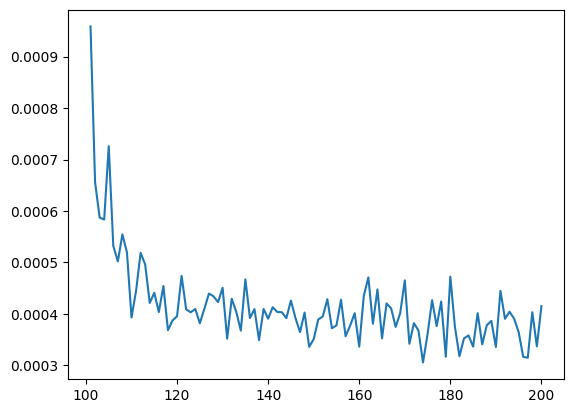

In [6]:
# plot learning stats
learning_stats = pd.read_csv(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial2\active_updates\dino\ModelsToTune\Canari-Tyler_Finetune-2026-06-15\dlc-models-pytorch\iteration-0\CanariJun15-trainset95shuffle1\train\learning_stats.csv")
learning_stats.head()
plt.plot(learning_stats["step"], learning_stats["losses/train.total_loss"], label="train_loss")

In [ ]:
dlc.analyze_videos(
    combined_config,
    [str(Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial2\Cam1.avi")), str(Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial2\Cam2.avi"))],
    save_as_csv=True,
    destfolder=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial2\active_updates\dino",
    batchsize=16
)

In [ ]:
xt.dlc_to_xma(
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial2\active_updates\dino\Cam1DLC_Resnet50_CanariJun15shuffle1_snapshot_200.csv", 
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial2\active_updates\dino\Cam2DLC_Resnet50_CanariJun15shuffle1_snapshot_200.csv", 
    "ModelUpdateMonday", 
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial2")

In [ ]:
snapped_csv, snapped_df = snap_combined_predictions_to_dark_pixels(
    pred_csv=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial2\ModelUpdateMonday-Predicted2DPoints.csv",
    cam1_dir=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial2\Cam1",
    cam2_dir=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial2\Cam2",
    #out_csv=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\active_updates_trial8\ModelUpdate-Predicted2DPoints-snapped-dark.csv",
    window_size=4,
)

#### Trial 3: David Bowie
Opens mouth wide!

In [ ]:
snapped_csv, snapped_df = snap_combined_predictions_to_dark_pixels(
    pred_csv=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial3\NoUpdateModel-Predicted2DPoints.csv",
    cam1_dir=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial3\Cam1",
    cam2_dir=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial3\Cam2",
    #out_csv=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\active_updates_trial8\ModelUpdate-Predicted2DPoints-snapped-dark.csv",
    window_size=4,
)

In [ ]:
src_trial = Path(
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial3\active_updates\dino"
)

models = src_trial / "ModelsToTune"
models.mkdir(exist_ok=True)
# 1) Ensure we have a real DLC project config.yaml to write labeled-data into
# Replace dummy_video with any existing video file you already use for project init.
combined_config = dlcs.create_combined_project_if_missing(
    task="Canari",
    experimenter="Tyler_Finetune",
    combined_project_root=models,
    dummy_video=Path(
        r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial3\Cam1.avi"
    ),
)

# edit the config.yaml to add our 2D points CSV as a scorer with appropriate bodyparts and skeleton info
bodyparts_apply_df = dlcs.apply_bird_bodyparts_to_configs(
        {"DavidBowie": [combined_config]},
        strict=True,
    )

# 2) Build a clean trial folder for xma_to_dlc

clean_trial = src_trial / "ModelTraining"
clean_trial.mkdir(parents=True, exist_ok=True)

# Copy camera folders
for cam_folder in ["Cam1", "Cam2"]:
    src = src_trial / cam_folder
    dst = clean_trial / cam_folder
    if dst.exists():
        shutil.rmtree(dst)
    shutil.copytree(src, dst)

# Pick truth CSV and keep only coordinate columns
truth_csv = src_trial / "data/corrections_autosave.csv" 
df = pd.read_csv(truth_csv)

coord_cols = [c for c in df.columns if re.search(r"_cam[12]_[XY]$", c)]
clean_df = df[coord_cols]

# Name contains 2Dpoints so xrommtools picks it first
clean_points_csv = clean_trial / "UpdatedLabels-2Dpoints.csv"
clean_df.to_csv(clean_points_csv, index=False)

# 3) Build dataset from cleaned trial
dlcs.build_combined_dataset(
    combined_config=combined_config,      # real config.yaml path
    data_path=clean_trial,                # folder containing csv + Cam1 + Cam2
    dataset_name="For_Test_20_Eval17_Dino_n400_s125",
    experimenter="Tyler",
    nframes=30,
    frame_selection_seed=42,
)

In [ ]:
import time
snapshot_path = (
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\Model519\n400_T17\Canari-Tyler-2026-05-22\dlc-models-pytorch\iteration-0\CanariMay22-trainset95shuffle1\train\snapshot-100.pt"
)
t0 = time.perf_counter()
dlcs.create_and_train(
    config_path=combined_config,
    epochs=100,
    snapshot_path=snapshot_path
)
elapsed = time.perf_counter() - t0
print(elapsed)

Text(0, 0.5, 'Training Loss')

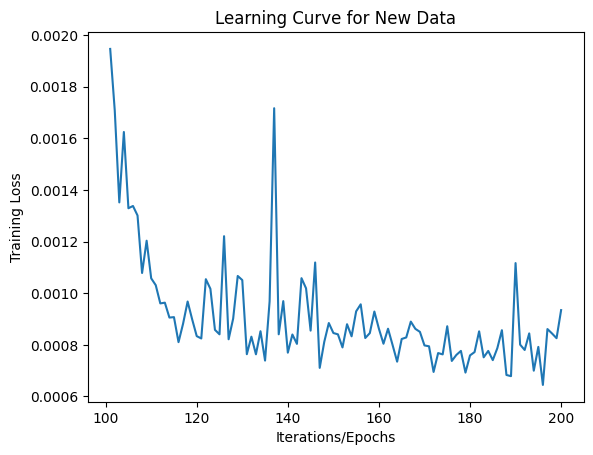

In [31]:
# plot learning stats
learning_stats = pd.read_csv(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\ActiveUpdates\Trial3\dino\ModelsToTune\Canari-Tyler_Finetune-2026-06-15\dlc-models-pytorch\iteration-0\CanariJun15-trainset95shuffle1\train\learning_stats.csv")
learning_stats.head()
plt.plot(learning_stats["step"], learning_stats["losses/train.total_loss"], label="train_loss")
plt.title("Learning Curve for New Data")
plt.xlabel("Iterations/Epochs")
plt.ylabel("Training Loss")

In [ ]:
dlc.analyze_videos(
    combined_config,
    [str(Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial3\Cam1.avi")), str(Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial3\Cam2.avi"))],
    save_as_csv=True,
    destfolder=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial3\active_updates\dino",
    batchsize=16
)

In [19]:
xt.dlc_to_xma(
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial3\active_updates\dino\Cam1DLC_Resnet50_CanariJun15shuffle1_snapshot_200.csv", 
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial3\active_updates\dino\Cam2DLC_Resnet50_CanariJun15shuffle1_snapshot_200.csv", 
    "ModelUpdateMonday", 
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial3")

In [ ]:
snapped_csv, snapped_df = snap_combined_predictions_to_dark_pixels(
    pred_csv=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial3\ModelUpdateMonday-Predicted2DPoints.csv",
    cam1_dir=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial3\Cam1",
    cam2_dir=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial3\Cam2",
    #out_csv=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\active_updates_trial8\ModelUpdate-Predicted2DPoints-snapped-dark.csv",
    window_size=4,
)

In [73]:
df_out = correct_frames_from_trial_dir(
    trial_dir=Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial3"),
    frames_to_correct=list(range(2280, 5262)),
    max_match_dist=15.0,
    image_collector=collect_images,
    correction_fn=_correct_camera_frame,
)

Corrected 25/2982 frames
Corrected 50/2982 frames
Corrected 75/2982 frames
Corrected 100/2982 frames
Corrected 125/2982 frames
Corrected 150/2982 frames
Corrected 175/2982 frames
Corrected 200/2982 frames
Corrected 225/2982 frames
Corrected 250/2982 frames
Corrected 275/2982 frames
Corrected 300/2982 frames
Corrected 325/2982 frames
Corrected 350/2982 frames
Corrected 375/2982 frames
Corrected 400/2982 frames
Corrected 425/2982 frames
Corrected 450/2982 frames
Corrected 475/2982 frames
Corrected 500/2982 frames
Corrected 525/2982 frames
Corrected 550/2982 frames
Corrected 575/2982 frames
Corrected 600/2982 frames
Corrected 625/2982 frames
Corrected 650/2982 frames
Corrected 675/2982 frames
Corrected 700/2982 frames
Corrected 725/2982 frames
Corrected 750/2982 frames
Corrected 775/2982 frames
Corrected 800/2982 frames
Corrected 825/2982 frames
Corrected 850/2982 frames
Corrected 875/2982 frames
Corrected 900/2982 frames
Corrected 925/2982 frames
Corrected 950/2982 frames
Corrected 975/2

#### Trial 4: David Bowie


In [ ]:
snapped_csv, snapped_df = snap_combined_predictions_to_dark_pixels(
    pred_csv=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial4\NoUpdateModel-Predicted2DPoints.csv",
    cam1_dir=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial4\Cam1",
    cam2_dir=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial4\Cam2",
    #out_csv=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\active_updates_trial8\ModelUpdate-Predicted2DPoints-snapped-dark.csv",
    window_size=4,
)

#### Trial 5: David Bowie


In [ ]:
snapped_csv, snapped_df = snap_combined_predictions_to_dark_pixels(
    pred_csv=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial5\NoUpdateModel-Predicted2DPoints.csv",
    cam1_dir=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial5\Cam1",
    cam2_dir=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial5\Cam2",
    #out_csv=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\active_updates_trial8\ModelUpdate-Predicted2DPoints-snapped-dark.csv",
    window_size=4,
)

In [ ]:
src_trial = Path(
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial5\active_updates\dino"
)

models = src_trial / "ModelsToTune"
models.mkdir(exist_ok=True)
# 1) Ensure we have a real DLC project config.yaml to write labeled-data into
# Replace dummy_video with any existing video file you already use for project init.
combined_config = dlcs.create_combined_project_if_missing(
    task="Canari",
    experimenter="Tyler_Finetune",
    combined_project_root=models,
    dummy_video=Path(
        r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial5\Cam1.avi"
    ),
)

# edit the config.yaml to add our 2D points CSV as a scorer with appropriate bodyparts and skeleton info
bodyparts_apply_df = dlcs.apply_bird_bodyparts_to_configs(
        {"DavidBowie": [combined_config]},
        strict=True,
    )

# 2) Build a clean trial folder for xma_to_dlc

clean_trial = src_trial / "ModelTraining"
clean_trial.mkdir(parents=True, exist_ok=True)

# Copy camera folders
for cam_folder in ["Cam1", "Cam2"]:
    src = src_trial / cam_folder
    dst = clean_trial / cam_folder
    if dst.exists():
        shutil.rmtree(dst)
    shutil.copytree(src, dst)

# Pick truth CSV and keep only coordinate columns
truth_csv = src_trial / "data/corrections_autosave.csv" 
df = pd.read_csv(truth_csv)

coord_cols = [c for c in df.columns if re.search(r"_cam[12]_[XY]$", c)]
clean_df = df[coord_cols]

# Name contains 2Dpoints so xrommtools picks it first
clean_points_csv = clean_trial / "UpdatedLabels-2Dpoints.csv"
clean_df.to_csv(clean_points_csv, index=False)

# 3) Build dataset from cleaned trial
dlcs.build_combined_dataset(
    combined_config=combined_config,      # real config.yaml path
    data_path=clean_trial,                # folder containing csv + Cam1 + Cam2
    dataset_name="UpdateTrial5-30",
    experimenter="Tyler",
    nframes=30,
    frame_selection_seed=42,
)

import time
snapshot_path = (
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\Model519\n400_T17\Canari-Tyler-2026-05-22\dlc-models-pytorch\iteration-0\CanariMay22-trainset95shuffle1\train\snapshot-100.pt"
)
t0 = time.perf_counter()
dlcs.create_and_train(
    config_path=combined_config,
    epochs=100,
    snapshot_path=snapshot_path
)
elapsed = time.perf_counter() - t0
print(elapsed)

In [ ]:
# plot learning stats
learning_stats = pd.read_csv(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial5\active_updates\dino\ModelsToTune\Canari-Tyler_Finetune-2026-06-17\dlc-models-pytorch\iteration-0\CanariJun17-trainset95shuffle1\train\learning_stats.csv")
learning_stats.head()
plt.plot(learning_stats["step"], learning_stats["losses/train.total_loss"], label="train_loss")
plt.show()

dlc.analyze_videos(
    combined_config,
    [str(Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial5\Cam1.avi")), str(Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial5\Cam2.avi"))],
    save_as_csv=True,
    destfolder=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial5\active_updates\dino",
    batchsize=16
)

xt.dlc_to_xma(
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial5\active_updates\dino\Cam1DLC_Resnet50_CanariJun17shuffle1_snapshot_200.csv", 
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial5\active_updates\dino\Cam2DLC_Resnet50_CanariJun17shuffle1_snapshot_200.csv", 
    "ModelUpdate", 
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial5")

snapped_csv, snapped_df = snap_combined_predictions_to_dark_pixels(
    pred_csv=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial5\ModelUpdate-Predicted2DPoints.csv",
    cam1_dir=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial5\Cam1",
    cam2_dir=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial5\Cam2",
    #out_csv=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\active_updates_trial8\ModelUpdate-Predicted2DPoints-snapped-dark.csv",
    window_size=4,
)

In [76]:
df_out = correct_frames_from_trial_dir(
    trial_dir=Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial5"),
    frames_to_correct=list(range(2224, 5200)),
    max_match_dist=15.0,
    image_collector=collect_images,
    correction_fn=_correct_camera_frame,
)

Corrected 25/2976 frames
Corrected 50/2976 frames
Corrected 75/2976 frames
Corrected 100/2976 frames
Corrected 125/2976 frames
Corrected 150/2976 frames
Corrected 175/2976 frames
Corrected 200/2976 frames
Corrected 225/2976 frames
Corrected 250/2976 frames
Corrected 275/2976 frames
Corrected 300/2976 frames
Corrected 325/2976 frames
Corrected 350/2976 frames
Corrected 375/2976 frames
Corrected 400/2976 frames
Corrected 425/2976 frames
Corrected 450/2976 frames
Corrected 475/2976 frames
Corrected 500/2976 frames
Corrected 525/2976 frames
Corrected 550/2976 frames
Corrected 575/2976 frames
Corrected 600/2976 frames
Corrected 625/2976 frames
Corrected 650/2976 frames
Corrected 675/2976 frames
Corrected 700/2976 frames
Corrected 725/2976 frames
Corrected 750/2976 frames
Corrected 775/2976 frames
Corrected 800/2976 frames
Corrected 825/2976 frames
Corrected 850/2976 frames
Corrected 875/2976 frames
Corrected 900/2976 frames
Corrected 925/2976 frames
Corrected 950/2976 frames
Corrected 975/2

#### Trial 6: David Bowie


In [ ]:
snapped_csv, snapped_df = snap_combined_predictions_to_dark_pixels(
    pred_csv=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial6\NoUpdateModel-Predicted2DPoints.csv",
    cam1_dir=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial6\Cam1",
    cam2_dir=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial6\Cam2",
    #out_csv=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\active_updates_trial8\ModelUpdate-Predicted2DPoints-snapped-dark.csv",
    window_size=4,
)

#### Trial 7: David Bowie

In [ ]:
snapped_csv, snapped_df = snap_combined_predictions_to_dark_pixels(
    pred_csv=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial7\NoUpdateModel-Predicted2DPoints.csv",
    cam1_dir=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial7\Cam1",
    cam2_dir=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial7\Cam2",
    #out_csv=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\active_updates_trial8\ModelUpdate-Predicted2DPoints-snapped-dark.csv",
    window_size=4,
)

#### Trial 9: David Bowie

n'existe pas

In [41]:
DavidBowie_Config = r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\Model519\n400_T17\Canari-Tyler-2026-05-22\config.yaml"

In [ ]:
predict_trial_from_jpg_stacks(
    DavidBowie_Config,
    "DavidBowie",
    9,
    base_processing_dir=Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData"),
    fps=500,
    batchsize=16,
    save_as_csv=True,
    xma_base_name="ModelUpdate",
    snap_window_size=4,
)

In [ ]:
snapped_csv, snapped_df = snap_combined_predictions_to_dark_pixels(
    pred_csv=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial9\NoUpdateModel-Predicted2DPoints.csv",
    cam1_dir=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial9\Cam1",
    cam2_dir=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial9\Cam2",
    #out_csv=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\active_updates_trial8\ModelUpdate-Predicted2DPoints-snapped-dark.csv",
    window_size=4,
)

#### Trial 10: David Bowie

In [ ]:
predict_trial_from_jpg_stacks(
    DavidBowie_Config,
    "DavidBowie",
    10,
    base_processing_dir=Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData"),
    fps=500,
    batchsize=16,
    save_as_csv=True,
    xma_base_name="ModelUpdate",
    snap_window_size=4,
)

#### Trial 11: David Bowie

In [ ]:
predict_trial_from_jpg_stacks(
    DavidBowie_Config,
    "DavidBowie",
    11,
    base_processing_dir=Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData"),
    fps=500,
    batchsize=16,
    save_as_csv=True,
    xma_base_name="ModelUpdate",
    snap_window_size=4,
)

In [ ]:
train_update_model(bird = "DavidBowie", trial_num=11)

In [ ]:
## Must Remove the -best from the snapshots
run_model_update(bird = "DavidBowie", trial_num=11)

In [77]:
df_out = correct_frames_from_trial_dir(
    trial_dir=Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial11"),
    frames_to_correct=list(range(2063, 4993)),
    max_match_dist=15.0,
    image_collector=collect_images,
    correction_fn=_correct_camera_frame,
)

Cam mismatch: Cam1=5666, Cam2=5138
Corrected 25/2930 frames
Corrected 50/2930 frames
Corrected 75/2930 frames
Corrected 100/2930 frames
Corrected 125/2930 frames
Corrected 150/2930 frames
Corrected 175/2930 frames
Corrected 200/2930 frames
Corrected 225/2930 frames
Corrected 250/2930 frames
Corrected 275/2930 frames
Corrected 300/2930 frames
Corrected 325/2930 frames
Corrected 350/2930 frames
Corrected 375/2930 frames
Corrected 400/2930 frames
Corrected 425/2930 frames
Corrected 450/2930 frames
Corrected 475/2930 frames
Corrected 500/2930 frames
Corrected 525/2930 frames
Corrected 550/2930 frames
Corrected 575/2930 frames
Corrected 600/2930 frames
Corrected 625/2930 frames
Corrected 650/2930 frames
Corrected 675/2930 frames
Corrected 700/2930 frames
Corrected 725/2930 frames
Corrected 750/2930 frames
Corrected 775/2930 frames
Corrected 800/2930 frames
Corrected 825/2930 frames
Corrected 850/2930 frames
Corrected 875/2930 frames
Corrected 900/2930 frames
Corrected 925/2930 frames
Correc

#### Trial 12

In [ ]:
predict_trial_from_jpg_stacks(
    DavidBowie_Config,
    "DavidBowie",
    12,
    base_processing_dir=Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData"),
    fps=500,
    batchsize=16,
    save_as_csv=True,
    xma_base_name="ModelUpdate",
    snap_window_size=4,
)

In [ ]:
train_update_model(bird="DavidBowie", trial_num=12)

In [ ]:
run_model_update(bird = "DavidBowie", trial_num=12)

In [ ]:
df_out = correct_frames_from_trial_dir(
    trial_dir=Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial12"),
    frames_to_correct=list(range(2495, 5320)),
    max_match_dist=15.0,
    image_collector=collect_images,
    correction_fn=_correct_camera_frame,
)

#### Trial 13

In [ ]:
predict_trial_from_jpg_stacks(
    DavidBowie_Config,
    "DavidBowie",
    13,
    base_processing_dir=Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData"),
    fps=500,
    batchsize=16,
    save_as_csv=True,
    xma_base_name="ModelUpdate",
    snap_window_size=4,
)

#### Trial 14

In [ ]:
predict_trial_from_jpg_stacks(
    DavidBowie_Config,
    "DavidBowie",
    14,
    base_processing_dir=Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData"),
    fps=500,
    batchsize=16,
    save_as_csv=True,
    xma_base_name="ModelUpdate",
    snap_window_size=4,
)

In [ ]:
train_update_model(bird="DavidBowie", trial_num=14)

In [ ]:
run_model_update(bird = "DavidBowie", trial_num=14)

In [ ]:
df_out = correct_frames_from_trial_dir(
    trial_dir=Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial14"),
    frames_to_correct=list(range(2454, 5413)),
    max_match_dist=15.0,
    image_collector=collect_images,
    correction_fn=_correct_camera_frame,
)

#### Trial 16

In [ ]:
predict_trial_from_jpg_stacks(
    DavidBowie_Config,
    "DavidBowie",
    16,
    base_processing_dir=Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData"),
    fps=500,
    batchsize=16,
    save_as_csv=True,
    xma_base_name="ModelUpdate",
    snap_window_size=4,
)

# Tulio Training First Model

Selected data from dino method first from the whole set to train first model (chose 100 frames)

In [ ]:
src_trial = Path(
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial10\active_updates\dino"
)

models = src_trial / "Model"
models.mkdir(exist_ok=True)
# 1) Ensure we have a real DLC project config.yaml to write labeled-data into
# Replace dummy_video with any existing video file you already use for project init.
combined_config = dlcs.create_combined_project_if_missing(
    task="Tulio",
    experimenter="Tyler",
    combined_project_root=models,
    dummy_video=Path(
        r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\Tulio\Cam1.avi"
    ),
)

# edit the config.yaml to add our 2D points CSV as a scorer with appropriate bodyparts and skeleton info
bodyparts_apply_df = dlcs.apply_bird_bodyparts_to_configs(
        {"Tulio": [combined_config]},
        strict=True,
    )

# 2) Build a clean trial folder for xma_to_dlc

clean_trial = src_trial / "ModelTraining"
clean_trial.mkdir(parents=True, exist_ok=True)

# Copy camera folders
for cam_folder in ["Cam1", "Cam2"]:
    src = src_trial / cam_folder
    dst = clean_trial / cam_folder
    if dst.exists():
        shutil.rmtree(dst)
    shutil.copytree(src, dst)

# Pick truth CSV and keep only coordinate columns
truth_csv = r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial10\active_updates\dino\data\LabeledBodyPartsCoordinates.csv"
df = pd.read_csv(truth_csv)

coord_cols = [c for c in df.columns if re.search(r"_cam[12]_[XY]$", c)]
clean_df = df[coord_cols]

# Name contains 2Dpoints so xrommtools picks it first
clean_points_csv = clean_trial / "UpdatedLabels-2Dpoints.csv"
clean_df.to_csv(clean_points_csv, index=False)

# 3) Build dataset from cleaned trial
dlcs.build_combined_dataset(
    combined_config=combined_config,      # real config.yaml path
    data_path=clean_trial,                # folder containing csv + Cam1 + Cam2
    dataset_name="TulioDiverseData300",
    experimenter="Tyler",
    nframes=300,
    frame_selection_seed=42,
)

In [ ]:
import time

t0 = time.perf_counter()
dlcs.create_and_train(
    config_path=combined_config,
    epochs=100,
)
elapsed = time.perf_counter() - t0
print(elapsed)

#### Trial 1: Tulio

In [23]:
config_path_tulio = r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\Tulio\SmallSetTraining\Model\Tulio-Tyler_Finetune-2026-06-16\config.yaml"

In [8]:
dc.jpg_stack_to_avi(
    input_folder=Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial1\Cam1"),
    output_path=Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial1\Cam1.avi"),
    fps=500)


dc.jpg_stack_to_avi(
    input_folder=Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial1\Cam2"),
    output_path=Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial1\Cam2.avi"),
    fps=500)

{'output_path': 'C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\ProcessingData\\Tulio\\Trial1\\Cam2.avi',
 'frames_written': 6001,
 'fps': 500,
 'codec': 'MJPG',
 'width': 768,
 'height': 768}

In [ ]:
dlc.analyze_videos(
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\Tulio\SmallSetTraining\Model\Tulio-Tyler_Finetune-2026-06-16\config.yaml",
    [str(Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial1\Cam1.avi")), str(Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial1\Cam2.avi"))],
    save_as_csv=True,
    destfolder=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial1",
    batchsize=16
)

In [ ]:
xt.dlc_to_xma(
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial1\Cam1DLC_Resnet50_TulioJun16shuffle1_snapshot_100.csv", 
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial1\Cam2DLC_Resnet50_TulioJun16shuffle1_snapshot_100.csv", 
    "ModelPredicted", 
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial1")

snapped_csv, snapped_df = snap_combined_predictions_to_dark_pixels(
    pred_csv=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial1\ModelPredicted-Predicted2DPoints.csv",
    cam1_dir=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial1\Cam1",
    cam2_dir=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial1\Cam2",
    #out_csv=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\active_updates_trial8\ModelUpdate-Predicted2DPoints-snapped-dark.csv",
    window_size=4,
)

#### Trial 3: Tulio

In [ ]:
predict_trial_from_jpg_stacks(
    config_path_tulio,
    "Tulio",
    3,
    base_processing_dir=Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData"),
    fps=500,
    batchsize=16,
    save_as_csv=True,
    xma_base_name="ModelUpdate",
    snap_window_size=4,
)

In [ ]:
train_update_model(
    bird= 'Tulio',
    trial_num = 3
    )

In [ ]:
dlc.analyze_videos(
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial3\active_updates\dino\ModelsToTune\Canari-Tyler_Finetune-2026-06-25\config.yaml",
    [str(Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial3\Cam1.avi")), str(Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial3\Cam2.avi"))],
    save_as_csv=True,
    destfolder=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial3\Updated",
    batchsize=16
)

In [25]:
xt.dlc_to_xma(
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial3\Updated\Cam1DLC_Resnet50_CanariJun25shuffle1_snapshot_200.csv", 
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial3\Updated\Cam2DLC_Resnet50_CanariJun25shuffle1_snapshot_200.csv", 
    "ModelUpdateMonday", 
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial3\Updated")

In [ ]:
df_out = correct_frames_from_trial_dir(
    trial_dir=Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial3"),
    frames_to_correct=list(range(2565, 5524)),
    max_match_dist=15.0,
    image_collector=collect_images,
    correction_fn=_correct_camera_frame,
)

#### Trial 4: Tulio


In [ ]:
predict_trial_from_jpg_stacks(
    config_path_tulio,
    "Tulio",
    4,
    base_processing_dir=Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData"),
    fps=500,
    batchsize=16,
    save_as_csv=True,
    xma_base_name="ModelUpdate",
    snap_window_size=4,
)

#### Trial 5: Tulio

In [ ]:
predict_trial_from_jpg_stacks(
    config_path_tulio,
    "Tulio",
    5,
    base_processing_dir=Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData"),
    fps=500,
    batchsize=16,
    save_as_csv=True,
    xma_base_name="ModelUpdate",
    snap_window_size=4,
)

In [ ]:
train_update_model(
    bird= 'Tulio',
    trial_num = 5
    )

In [ ]:
run_model_update("Tulio", 5)

#### Trial 6: Tulio

In [ ]:
predict_trial_from_jpg_stacks(
    config_path_tulio,
    "Tulio",
    6,
    base_processing_dir=Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData"),
    fps=500,
    batchsize=16,
    save_as_csv=True,
    xma_base_name="ModelUpdate",
    snap_window_size=4,
)

#### Trial 7: Tulio

In [ ]:
predict_trial_from_jpg_stacks(
    config_path_tulio,
    "Tulio",
    7,
    base_processing_dir=Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData"),
    fps=500,
    batchsize=16,
    save_as_csv=True,
    xma_base_name="ModelUpdate",
    snap_window_size=4,
)

#### Trial 8: Tulio

In [ ]:
predict_trial_from_jpg_stacks(
    config_path_tulio,
    "Tulio",
    8,
    base_processing_dir=Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData"),
    fps=500,
    batchsize=16,
    save_as_csv=True,
    xma_base_name="ModelUpdate",
    snap_window_size=4,
)

In [ ]:
train_update_model(
    bird= 'Tulio',
    trial_num = 8
    )

## Must Remove the -best from the snapshots
run_model_update(
    bird="Tulio",
    trial_num = 8
    )

In [ ]:
snapped_csv, snapped_df = snap_combined_predictions_to_dark_pixels(
    pred_csv=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial8\ModelUpdateMonday-Predicted2DPoints.csv",
    cam1_dir=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial8\Cam1",
    cam2_dir=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial8\Cam2",
    #out_csv=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\active_updates_trial8\ModelUpdate-Predicted2DPoints-snapped-dark.csv",
    window_size=4,
)

#### Trial 9: Tulio

##### First Round Predictions

In [ ]:
predict_trial_from_jpg_stacks(
    combined_config,
    "Tulio",
    9,
    base_processing_dir=Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData"),
    fps=500,
    batchsize=16,
    save_as_csv=True,
    xma_base_name="ModelUpdate",
    snap_window_size=4,
)

##### Updating Model

#### Unifying the active updates of different methods

In [ ]:
from pathlib import Path
import shutil
import re
import pandas as pd


def _extract_image_index(image_name: str) -> int:
    match = re.search(r"(\d+)(?=\.[^.]+$)", Path(image_name).name)
    if match is None:
        raise ValueError(f"Could not extract image index from '{image_name}'.")
    return int(match.group(1))


def unify_active_update_sets(
    source_root: str | Path,
    update_names: tuple[str, ...] = ("dino", "displacement"),
    unified_name: str = "unified",
    overwrite: bool = True,
) -> Path:
    source_root = Path(source_root)
    unified_dir = source_root / unified_name
    update_dirs = [source_root / name for name in update_names]

    missing = [path for path in update_dirs if not path.exists()]
    if missing:
        missing_text = "\n".join(str(path) for path in missing)
        raise FileNotFoundError(f"Missing active update folders:\n{missing_text}")

    if unified_dir.exists() and overwrite:
        shutil.rmtree(unified_dir)

    for subdir in ("cam1", "cam2", "data"):
        (unified_dir / subdir).mkdir(parents=True, exist_ok=True)

    def copy_image_union(camera_folder: str) -> list[int]:
        indexed_paths: dict[int, Path] = {}

        for update_dir in update_dirs:
            for image_path in sorted(path for path in (update_dir / camera_folder).iterdir() if path.is_file()):
                image_index = _extract_image_index(image_path.name)
                if image_index in indexed_paths:
                    raise ValueError(
                        f"Duplicate {camera_folder} image index {image_index} found while merging into {unified_dir}."
                    )
                indexed_paths[image_index] = image_path

        for image_index, image_path in sorted(indexed_paths.items()):
            shutil.copy2(image_path, unified_dir / camera_folder / image_path.name)

        return sorted(indexed_paths)

    cam1_indices = copy_image_union("cam1")
    cam2_indices = copy_image_union("cam2")

    if cam1_indices != cam2_indices:
        raise ValueError("Cam1 and Cam2 image indices do not match after merging.")

    merged_frames = []
    expected_columns = None

    for source_priority, update_dir in enumerate(update_dirs):
        corrections_csv = update_dir / "data" / "corrections_autosave.csv"
        if not corrections_csv.exists():
            raise FileNotFoundError(f"Missing labels CSV:\n{corrections_csv}")

        df = pd.read_csv(corrections_csv).copy()

        if expected_columns is None:
            expected_columns = list(df.columns)
        elif list(df.columns) != expected_columns:
            raise ValueError(
                f"CSV columns do not match between update sets.\n"
                f"Expected: {expected_columns}\n"
                f"Found: {list(df.columns)}"
            )

        df["_image_index"] = df["image_cam1"].map(_extract_image_index)
        df["_source_priority"] = source_priority

        if df["_image_index"].duplicated().any():
            duplicates = df.loc[df["_image_index"].duplicated(), "_image_index"].tolist()
            raise ValueError(
                f"Duplicate frame indices found within {corrections_csv}: {duplicates[:10]}"
            )

        merged_frames.append(df)

    merged_df = pd.concat(merged_frames, ignore_index=True)
    merged_df = merged_df.sort_values(["_image_index", "_source_priority"], kind="stable")
    merged_df = merged_df.drop_duplicates(subset="_image_index", keep="first")

    merged_indices = merged_df["_image_index"].tolist()
    if merged_indices != cam1_indices:
        raise ValueError(
            "Merged CSV frame order does not match merged image order.\n"
            f"Images: {cam1_indices[:10]} ...\n"
            f"CSV: {merged_indices[:10]} ..."
        )

    if "frame_pos" in merged_df.columns:
        merged_df["frame_pos"] = range(len(merged_df))

    merged_df = merged_df.drop(columns=["_image_index", "_source_priority"])
    merged_df = merged_df[expected_columns]
    merged_df.to_csv(unified_dir / "data" / "corrections_autosave.csv", index=False)

    for update_dir in update_dirs:
        for extra_file in sorted((update_dir / "data").iterdir()):
            if not extra_file.is_file() or extra_file.name == "corrections_autosave.csv":
                continue
            dest_file = unified_dir / "data" / extra_file.name
            if dest_file.exists():
                raise ValueError(f"Duplicate extra data file name while merging: {extra_file.name}")
            shutil.copy2(extra_file, dest_file)

    print(f"Created unified update folder: {unified_dir}")
    print(f"Merged {len(cam1_indices)} frames from: {', '.join(update_names)}")
    return unified_dir



Created unified update folder: C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\active_updates\Trial9\unified
Merged 70 frames from: dino, displacement


WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/ProcessingData/Tulio/active_updates/Trial9/unified')

In [ ]:

trial9_unified = unify_active_update_sets(
    source_root=Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\active_updates\Trial9"),
    update_names=("dino", "displacement"),
    unified_name="unified",
    overwrite=True,
)


In [ ]:
train_update_model(
    bird='Tulio',
    trial_num=9,
    update_set='unified',
)

In [ ]:
## Must Remove the -best from the snapshots
run_model_update(
    bird="Tulio",
    trial_num=9,
    update_set="unified",
)

In [65]:
import cv2
import time

# ------------------------------------------------------------------
# Inputs
# ------------------------------------------------------------------
pred_csv = Path(
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial9\ModelUpdateMonday-Predicted2DPoints.csv"
)
out_csv = Path(
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial9\df_corrected.csv"
)

cam_dirs = {
    "cam1": Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial9\Cam1"),
    "cam2": Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial9\Cam2"),
}

# Choose either a contiguous range OR an explicit list.
# Example contiguous range (inclusive):
start_frame = 2581
end_frame = 5381
frames_to_correct = list(range(start_frame, end_frame + 1))

# Example explicit list:
# frames_to_correct = [5549, 5550, 5602]

max_match_dist = 15.0

# ------------------------------------------------------------------
# Load data and image indexes
# ------------------------------------------------------------------
df = pd.read_csv(pred_csv)
df_corrected = df.copy(deep=True)

image_paths = {
    camera: collect_images(folder)
    for camera, folder in cam_dirs.items()
}

if len(image_paths["cam1"]) != len(image_paths["cam2"]):
    raise ValueError(
        f"Cam image count mismatch: cam1={len(image_paths['cam1'])}, cam2={len(image_paths['cam2'])}"
    )

# Keep only valid frame indices
valid_frames = [
    i for i in sorted(set(int(x) for x in frames_to_correct))
    if 0 <= i < len(df_corrected) and i < len(image_paths["cam1"]) and i < len(image_paths["cam2"])
]

if not valid_frames:
    raise ValueError("No valid frames to correct after bounds checking.")

# ------------------------------------------------------------------
# Correct selected frames (camera-correct image source)
# ------------------------------------------------------------------
t0 = time.perf_counter()

for n, frame_idx in enumerate(valid_frames, start=1):
    row = df_corrected.iloc[frame_idx]

    for camera in ("cam1", "cam2"):
        image_path = image_paths[camera][frame_idx]

        # cv2 grayscale read is typically faster than skimage.io.imread for this loop.
        gray = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
        if gray is None:
            continue

        updates = _correct_camera_frame(
            image=gray,
            row=row,
            camera=camera,
            max_match_dist=max_match_dist,
        )

        if updates:
            df_corrected.loc[df_corrected.index[frame_idx], list(updates.keys())] = list(updates.values())

    if n % 25 == 0 or n == len(valid_frames):
        print(f"Corrected {n}/{len(valid_frames)} frames")

elapsed = time.perf_counter() - t0

df_corrected.to_csv(out_csv, index=False)
print(f"Saved corrected CSV: {out_csv}")
print(f"Finished correcting {len(valid_frames)} selected frames in {elapsed:.1f}s")

Corrected 25/2801 frames
Corrected 50/2801 frames
Corrected 75/2801 frames
Corrected 100/2801 frames
Corrected 125/2801 frames
Corrected 150/2801 frames
Corrected 175/2801 frames
Corrected 200/2801 frames
Corrected 225/2801 frames
Corrected 250/2801 frames
Corrected 275/2801 frames
Corrected 300/2801 frames
Corrected 325/2801 frames
Corrected 350/2801 frames
Corrected 375/2801 frames
Corrected 400/2801 frames
Corrected 425/2801 frames
Corrected 450/2801 frames
Corrected 475/2801 frames
Corrected 500/2801 frames
Corrected 525/2801 frames
Corrected 550/2801 frames
Corrected 575/2801 frames
Corrected 600/2801 frames
Corrected 625/2801 frames
Corrected 650/2801 frames
Corrected 675/2801 frames
Corrected 700/2801 frames
Corrected 725/2801 frames
Corrected 750/2801 frames
Corrected 775/2801 frames
Corrected 800/2801 frames
Corrected 825/2801 frames
Corrected 850/2801 frames
Corrected 875/2801 frames
Corrected 900/2801 frames
Corrected 925/2801 frames
Corrected 950/2801 frames
Corrected 975/2

In [70]:
df_out = correct_frames_from_trial_dir(
    trial_dir=Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial8"),
    frames_to_correct=list(range(1812, 4675)),
    max_match_dist=15.0,
    image_collector=collect_images,
    correction_fn=_correct_camera_frame,
)

Cam mismatch: Cam1=6001, Cam2=5920
Corrected 25/2863 frames
Corrected 50/2863 frames
Corrected 75/2863 frames
Corrected 100/2863 frames
Corrected 125/2863 frames
Corrected 150/2863 frames
Corrected 175/2863 frames
Corrected 200/2863 frames
Corrected 225/2863 frames
Corrected 250/2863 frames
Corrected 275/2863 frames
Corrected 300/2863 frames
Corrected 325/2863 frames
Corrected 350/2863 frames
Corrected 375/2863 frames
Corrected 400/2863 frames
Corrected 425/2863 frames
Corrected 450/2863 frames
Corrected 475/2863 frames
Corrected 500/2863 frames
Corrected 525/2863 frames
Corrected 550/2863 frames
Corrected 575/2863 frames
Corrected 600/2863 frames
Corrected 625/2863 frames
Corrected 650/2863 frames
Corrected 675/2863 frames
Corrected 700/2863 frames
Corrected 725/2863 frames
Corrected 750/2863 frames
Corrected 775/2863 frames
Corrected 800/2863 frames
Corrected 825/2863 frames
Corrected 850/2863 frames
Corrected 875/2863 frames
Corrected 900/2863 frames
Corrected 925/2863 frames
Correc

#### Trial 10: Tulio

In [ ]:
predict_trial_from_jpg_stacks(
    combined_config,
    "Tulio",
    10,
    base_processing_dir=Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData"),
    fps=500, 
    batchsize=16,
    save_as_csv=True,
    xma_base_name="ModelUpdate",
    snap_window_size=4,
)

Converting Cine Image stacks to AVI videos
Now To Analyze the videos with existing model!
Analyzing videos with C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\Tulio\SmallSetTraining\Model\Tulio-Tyler_Finetune-2026-06-16\dlc-models-pytorch\iteration-0\TulioJun16-trainset95shuffle1\train\snapshot-100.pt
Using scorer: DLC_Resnet50_TulioJun16shuffle1_snapshot_100
Starting to analyze C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial10\Cam1.avi
Video metadata: 
  Overall # of frames:    6001
  Duration of video [s]:  12.00
  fps:                    500.0
  resolution:             w=768, h=768

Running pose prediction with batch size 16


100%|██████████| 6001/6001 [03:00<00:00, 33.33it/s]


Saving results in C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial10\Cam1DLC_Resnet50_TulioJun16shuffle1_snapshot_100.h5 and C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial10\Cam1DLC_Resnet50_TulioJun16shuffle1_snapshot_100_full.pickle
Starting to analyze C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial10\Cam2.avi
Video metadata: 
  Overall # of frames:    6001
  Duration of video [s]:  12.00
  fps:                    500.0
  resolution:             w=768, h=768

Running pose prediction with batch size 16


100%|██████████| 6001/6001 [03:00<00:00, 33.32it/s]


Saving results in C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial10\Cam2DLC_Resnet50_TulioJun16shuffle1_snapshot_100.h5 and C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial10\Cam2DLC_Resnet50_TulioJun16shuffle1_snapshot_100_full.pickle
The videos are analyzed. Now your research can truly start!
You can create labeled videos with 'create_labeled_video'.
If the tracking is not satisfactory for some videos, consider expanding the training set. You can use the function 'extract_outlier_frames' to extract a few representative outlier frames.

Converting predictions to XMA format
Snapping predictions to darkest Pixel
Snapping 24 bodyparts across 6001 frames...
  frame 0/6000
  frame 100/6000
  frame 200/6000
  frame 300/6000
  frame 400/6000
  frame 500/6000
  frame 600/6000
  frame 700/6000
  frame 800/6000
  frame 900/6000
  frame 1000/6000
  frame 1100/6000
  frame 1200/6000
  frame 13

{'trial_dir': WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/ProcessingData/Tulio/Trial10'),
 'cam1_avi': WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/ProcessingData/Tulio/Trial10/Cam1.avi'),
 'cam2_avi': WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/ProcessingData/Tulio/Trial10/Cam2.avi'),
 'cam1_dlc_csv': WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/ProcessingData/Tulio/Trial10/Cam1DLC_Resnet50_TulioJun16shuffle1_snapshot_100.csv'),
 'cam2_dlc_csv': WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/ProcessingData/Tulio/Trial10/Cam2DLC_Resnet50_TulioJun16shuffle1_snapshot_100.csv'),
 'pred_csv': WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/ProcessingData/Tulio/Trial10/ModelUpdate-Predicted2DPoints.csv'),
 'snapped_csv': WindowsPath('C:/Users/Sal

#### Trial 11: Tulio

In [20]:
predict_trial_from_jpg_stacks(
    config_path_tulio,
    "Tulio",
    11,
    base_processing_dir=Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData"),
    fps=500,
    batchsize=16,
    save_as_csv=True,
    xma_base_name="ModelUpdate",
    snap_window_size=4,
)

Converting Cine Image stacks to AVI videos
Now To Analyze the videos with existing model!
Analyzing videos with C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\Tulio\SmallSetTraining\Model\Tulio-Tyler_Finetune-2026-06-16\dlc-models-pytorch\iteration-0\TulioJun16-trainset95shuffle1\train\snapshot-100.pt
Using scorer: DLC_Resnet50_TulioJun16shuffle1_snapshot_100
Starting to analyze C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial11\Cam1.avi
Video metadata: 
  Overall # of frames:    6001
  Duration of video [s]:  12.00
  fps:                    500.0
  resolution:             w=768, h=768

Running pose prediction with batch size 16


100%|██████████| 6001/6001 [02:52<00:00, 34.89it/s]


Saving results in C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial11\Cam1DLC_Resnet50_TulioJun16shuffle1_snapshot_100.h5 and C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial11\Cam1DLC_Resnet50_TulioJun16shuffle1_snapshot_100_full.pickle
Starting to analyze C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial11\Cam2.avi
Video metadata: 
  Overall # of frames:    11996
  Duration of video [s]:  23.99
  fps:                    500.0
  resolution:             w=768, h=768

Running pose prediction with batch size 16


100%|██████████| 11996/11996 [05:47<00:00, 34.57it/s]


Saving results in C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial11\Cam2DLC_Resnet50_TulioJun16shuffle1_snapshot_100.h5 and C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial11\Cam2DLC_Resnet50_TulioJun16shuffle1_snapshot_100_full.pickle
The videos are analyzed. Now your research can truly start!
You can create labeled videos with 'create_labeled_video'.
If the tracking is not satisfactory for some videos, consider expanding the training set. You can use the function 'extract_outlier_frames' to extract a few representative outlier frames.

Converting predictions to XMA format


C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\Code-Testing\xrommtools.py:290: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72) have mixed types. Specify dtype option on import or set low_memory=False.
  cam2data=pd.read_csv(cam2data, sep=',',header=None)
C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\Code-Testing\xrommtools.py:333: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block0_values] [items->Index(['CraniumRightPosterior_cam1_X', 'CraniumRightPosterior_cam1_Y',
       'CraniumRightPosterior_cam2_X', 'CraniumRightPosterior_cam2_Y',
       'CraniumLeftPosterior_cam1_X', 'CraniumLeftPosterior_cam1_Y',
       'CraniumLeftPosterior_cam2_X', 'Cr

Snapping predictions to darkest Pixel
Snapping 24 bodyparts across 11996 frames...
  frame 0/11995
  frame 100/11995
  frame 200/11995
  frame 300/11995
  frame 400/11995
  frame 500/11995
  frame 600/11995
  frame 700/11995
  frame 800/11995
  frame 900/11995
  frame 1000/11995
  frame 1100/11995
  frame 1200/11995
  frame 1300/11995
  frame 1400/11995
  frame 1500/11995
  frame 1600/11995
  frame 1700/11995
  frame 1800/11995
  frame 1900/11995
  frame 2000/11995
  frame 2100/11995
  frame 2200/11995
  frame 2300/11995
  frame 2400/11995
  frame 2500/11995
  frame 2600/11995
  frame 2700/11995
  frame 2800/11995
  frame 2900/11995
  frame 3000/11995
  frame 3100/11995
  frame 3200/11995
  frame 3300/11995
  frame 3400/11995
  frame 3500/11995
  frame 3600/11995
  frame 3700/11995
  frame 3800/11995
  frame 3900/11995
  frame 4000/11995
  frame 4100/11995
  frame 4200/11995
  frame 4300/11995
  frame 4400/11995
  frame 4500/11995
  frame 4600/11995
  frame 4700/11995
  frame 4800/1199

{'trial_dir': WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/ProcessingData/Tulio/Trial11'),
 'cam1_avi': WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/ProcessingData/Tulio/Trial11/Cam1.avi'),
 'cam2_avi': WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/ProcessingData/Tulio/Trial11/Cam2.avi'),
 'cam1_dlc_csv': WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/ProcessingData/Tulio/Trial11/Cam1DLC_Resnet50_TulioJun16shuffle1_snapshot_100.csv'),
 'cam2_dlc_csv': WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/ProcessingData/Tulio/Trial11/Cam2DLC_Resnet50_TulioJun16shuffle1_snapshot_100.csv'),
 'pred_csv': WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/ProcessingData/Tulio/Trial11/ModelUpdate-Predicted2DPoints.csv'),
 'snapped_csv': WindowsPath('C:/Users/Sal

#### Trial 12: Tulio

In [21]:
predict_trial_from_jpg_stacks(
    config_path_tulio,
    "Tulio",
    12,
    base_processing_dir=Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData"),
    fps=500,
    batchsize=16,
    save_as_csv=True,
    xma_base_name="ModelUpdate",
    snap_window_size=4,
)

Converting Cine Image stacks to AVI videos
Now To Analyze the videos with existing model!
Analyzing videos with C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\Tulio\SmallSetTraining\Model\Tulio-Tyler_Finetune-2026-06-16\dlc-models-pytorch\iteration-0\TulioJun16-trainset95shuffle1\train\snapshot-100.pt
Using scorer: DLC_Resnet50_TulioJun16shuffle1_snapshot_100
Starting to analyze C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial12\Cam2.avi
Video metadata: 
  Overall # of frames:    5896
  Duration of video [s]:  11.79
  fps:                    500.0
  resolution:             w=768, h=768

Running pose prediction with batch size 16


100%|██████████| 5896/5896 [02:48<00:00, 34.91it/s]


Saving results in C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial12\Cam2DLC_Resnet50_TulioJun16shuffle1_snapshot_100.h5 and C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial12\Cam2DLC_Resnet50_TulioJun16shuffle1_snapshot_100_full.pickle
Starting to analyze C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial12\Cam1.avi
Video metadata: 
  Overall # of frames:    6001
  Duration of video [s]:  12.00
  fps:                    500.0
  resolution:             w=768, h=768

Running pose prediction with batch size 16


100%|██████████| 6001/6001 [02:50<00:00, 35.30it/s]


Saving results in C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial12\Cam1DLC_Resnet50_TulioJun16shuffle1_snapshot_100.h5 and C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial12\Cam1DLC_Resnet50_TulioJun16shuffle1_snapshot_100_full.pickle
The videos are analyzed. Now your research can truly start!
You can create labeled videos with 'create_labeled_video'.
If the tracking is not satisfactory for some videos, consider expanding the training set. You can use the function 'extract_outlier_frames' to extract a few representative outlier frames.

Converting predictions to XMA format


C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\Code-Testing\xrommtools.py:333: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block0_values] [items->Index(['CraniumRightPosterior_cam1_X', 'CraniumRightPosterior_cam1_Y',
       'CraniumRightPosterior_cam2_X', 'CraniumRightPosterior_cam2_Y',
       'CraniumLeftPosterior_cam1_X', 'CraniumLeftPosterior_cam1_Y',
       'CraniumLeftPosterior_cam2_X', 'CraniumLeftPosterior_cam2_Y',
       'CraniumRightMiddle_cam1_X', 'CraniumRightMiddle_cam1_Y',
       'CraniumRightMiddle_cam2_X', 'CraniumRightMiddle_cam2_Y',
       'CraniumRightAnterior_cam1_X', 'CraniumRightAnterior_cam1_Y',
       'CraniumRightAnterior_cam2_X', 'CraniumRightAnterior_cam2_Y',
       'CraniumLeftAnterior_cam1_X', 'CraniumLeftAnterior_cam1_Y',
       'CraniumLeftAnterior_cam2_X', 'CraniumLeftAnterior_cam2_Y',
       'MaxillaRightPosterior_cam1_X'

Snapping predictions to darkest Pixel
Snapping 24 bodyparts across 6001 frames...
  frame 0/6000
  frame 100/6000
  frame 200/6000
  frame 300/6000
  frame 400/6000
  frame 500/6000
  frame 600/6000
  frame 700/6000
  frame 800/6000
  frame 900/6000
  frame 1000/6000
  frame 1100/6000
  frame 1200/6000
  frame 1300/6000
  frame 1400/6000
  frame 1500/6000
  frame 1600/6000
  frame 1700/6000
  frame 1800/6000
  frame 1900/6000
  frame 2000/6000
  frame 2100/6000
  frame 2200/6000
  frame 2300/6000
  frame 2400/6000
  frame 2500/6000
  frame 2600/6000
  frame 2700/6000
  frame 2800/6000
  frame 2900/6000
  frame 3000/6000
  frame 3100/6000
  frame 3200/6000
  frame 3300/6000
  frame 3400/6000
  frame 3500/6000
  frame 3600/6000
  frame 3700/6000
  frame 3800/6000
  frame 3900/6000
  frame 4000/6000
  frame 4100/6000
  frame 4200/6000
  frame 4300/6000
  frame 4400/6000
  frame 4500/6000
  frame 4600/6000
  frame 4700/6000
  frame 4800/6000
  frame 4900/6000
  frame 5000/6000
  frame 5100

{'trial_dir': WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/ProcessingData/Tulio/Trial12'),
 'cam1_avi': WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/ProcessingData/Tulio/Trial12/Cam1.avi'),
 'cam2_avi': WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/ProcessingData/Tulio/Trial12/Cam2.avi'),
 'cam1_dlc_csv': WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/ProcessingData/Tulio/Trial12/Cam1DLC_Resnet50_TulioJun16shuffle1_snapshot_100.csv'),
 'cam2_dlc_csv': WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/ProcessingData/Tulio/Trial12/Cam2DLC_Resnet50_TulioJun16shuffle1_snapshot_100.csv'),
 'pred_csv': WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/ProcessingData/Tulio/Trial12/ModelUpdate-Predicted2DPoints.csv'),
 'snapped_csv': WindowsPath('C:/Users/Sal